Train path: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation path: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Train exists: True
Validation exists: True
Found 70295 files belonging to 38 classes.


2026-09-27 04:20:14.186152: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 17572 files belonging to 38 classes.
Classes:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider

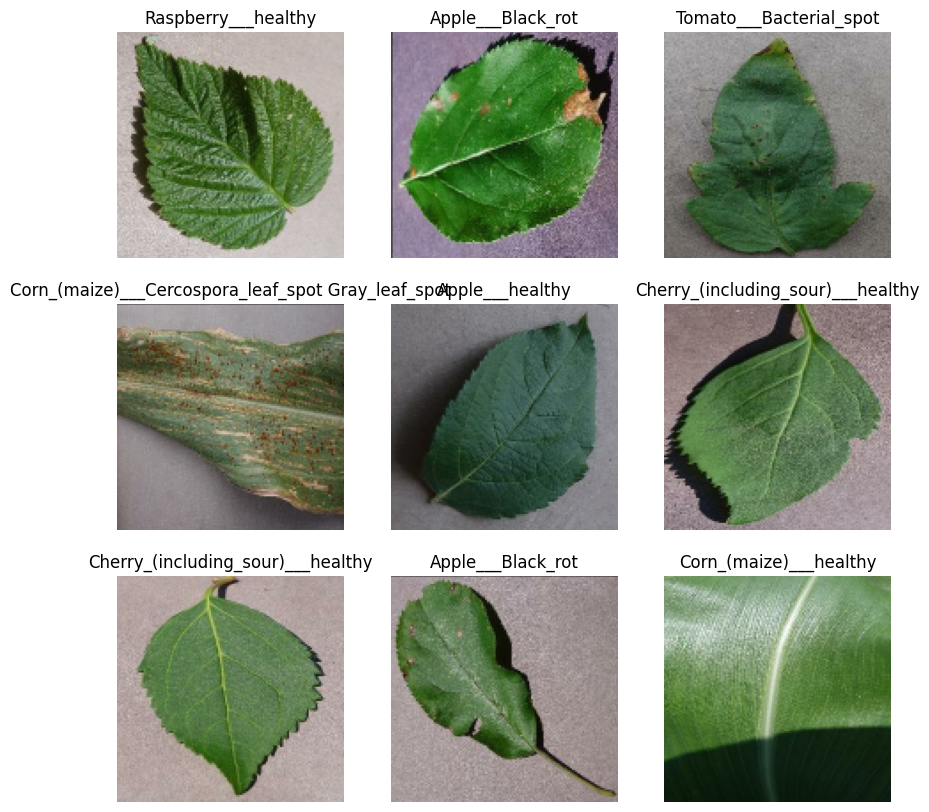

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1047s 476ms/step - accuracy: 0.5944 - loss: 1.3712 - val_accuracy: 0.8368 - val_loss: 0.5231
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7877 - loss: 0.6713

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# STEP 1: Dataset Path
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "valid")

print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)

print("Train exists:", os.path.exists(TRAIN_PATH))
print("Validation exists:", os.path.exists(VAL_PATH))


# ============================================================
# STEP 2: Image Parameters
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32


# ============================================================
# STEP 3: Load Training Dataset
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)


# ============================================================
# STEP 4: Load Validation Dataset
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)


# ============================================================
# STEP 5: Classes
# ============================================================

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:")
print(class_names)

print("Number of classes:", num_classes)


# ============================================================
# STEP 6: Normalize Pixel Values
# ============================================================

normalization = tf.keras.layers.Rescaling(1.0 / 255)


# ============================================================
# STEP 7: Improve Dataset Performance
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)


# ============================================================
# STEP 8: Display Sample Images
# ============================================================

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.show()


# ============================================================
# STEP 9: CNN Model
# ============================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    normalization,

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.3
    ),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])


# ============================================================
# STEP 10: Compile Model
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# STEP 11: Model Summary
# ============================================================

model.summary()


# ============================================================
# STEP 12: Train Model
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


# ============================================================
# STEP 13: Evaluate Model
# ============================================================

loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)

print("Validation Accuracy:", accuracy)

print(
    "Validation Accuracy (%):",
    accuracy * 100
)


# ============================================================
# STEP 14: Accuracy Graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "CNN Training and Validation Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# STEP 15: Loss Graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training and Validation Loss"
)

plt.legend()

plt.show()


# ============================================================
# STEP 16: Save Model
# ============================================================

MODEL_PATH = "/kaggle/working/plant_disease_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved at:", MODEL_PATH)








